# Bayesian updates from scratch — sequential conjugate inference

Notebook [0.4 — three parameterizations](natural_parameters.ipynb) showed that combining two Gaussian factors is **addition in natural-parameter space**. This notebook follows that thread to its conclusion: an inference loop that absorbs $N$ Gaussian observations one at a time, equivalent to processing them all at once, in any order, with the same answer to floating-point precision.

That single idea — *exponential-family inference reduces to summing natural parameters* — underlies the Kalman filter, GP regression, EP, and most of approximate inference. We make it concrete by

1. writing the linear-Gaussian Bayes rule once, in natural form, leaning on [](natural_parameters.ipynb#eq:natural-product);
2. running a sequential loop over $N=6$ noisy observations of an unknown 2D location;
3. confirming **batch = sequential = any-order** to $\sim 10^{-15}$;
4. closing with the punch line: GP regression with a Gaussian likelihood is a single application of the same rule.

Prerequisites: [0.2 — `MultivariateNormal` API](mvn_distribution_api.ipynb), [0.4 — three parameterizations](natural_parameters.ipynb), [0.5 — Joseph-form covariance update](joseph_form_update.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
import gaussx
from gaussx import GaussianExpFam, log_marginal_likelihood, solve, to_expectation, to_natural

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(42)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})


def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.symmetric_tag)


def ellipse_points(mu, Sigma, n_std=2.0, n=200):
    # Standard 2D confidence-ellipse construction via eigendecomposition.
    theta = jnp.linspace(0.0, 2.0 * jnp.pi, n)
    circle = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=0)
    eigvals, eigvecs = jnp.linalg.eigh(Sigma)
    sqrt_l = jnp.sqrt(eigvals) * n_std
    stretched = einx.multiply("j, j t -> j t", sqrt_l, circle)
    rotated   = einx.dot("i j, j t -> i t", eigvecs, stretched)
    return einx.add("i, i t -> i t", mu, rotated)

## Linear-Gaussian Bayes rule, in one breath

The linear-Gaussian observation model from [](joseph_form_update.ipynb#eq:lin-gauss-model) gives a Gaussian posterior with three equivalent updates:

```{math}
:label: eq:bayes-precision
\Lambda_{\rm post} \;=\; \Lambda_{\rm prior} \;+\; H^\top R^{-1} H,
\qquad
\Lambda_{\rm post}\,\mu_{\rm post} \;=\; \Lambda_{\rm prior}\,\mu_{\rm prior} \;+\; H^\top R^{-1} y.
```

In **natural parameters**, recalling $\eta_1 = \Lambda \mu$ and $\eta_2 = -\tfrac12 \Lambda$ from [](natural_parameters.ipynb#eq:meancov-to-natural), the rule is just [](natural_parameters.ipynb#eq:natural-product) applied to the *prior* and the *likelihood factor*:

```{math}
:label: eq:bayes-natural
\eta_1^{\rm post} \;=\; \eta_1^{\rm prior} + H^\top R^{-1} y,
\qquad
\eta_2^{\rm post} \;=\; \eta_2^{\rm prior} - \tfrac12\, H^\top R^{-1} H.
```

That's the entire algorithm. No matrix inverses, no Kalman gains. The mean-cov form [](joseph_form_update.ipynb#eq:kalman-mean) and Joseph form [](joseph_form_update.ipynb#eq:cov-joseph) are equivalent recipes for getting back to $(\mu, \Sigma)$ when you need to plot or sample.

:::{tip} ELI5
A Gaussian "posterior update" is just **two natural-parameter pairs added together**. The likelihood-factor's natural is $(H^\top R^{-1} y,\; -\tfrac12 H^\top R^{-1} H)$ — read off the linear-Gaussian model and add to whatever you've got. No matrices to invert until you need a covariance back.
:::

## A 2D location-estimation problem

We're trying to estimate an unknown 2D location $x_\star = (3,\,-1)$ from a sequence of noisy linear measurements. Start with a vague Gaussian prior $\mathcal{N}(\mathbf{0},\,4I)$ and convert it to natural form via `gaussx.to_natural`.

In [2]:
x_true = jnp.array([3.0, -1.0])

mu0    = jnp.zeros(2)
Sigma0 = 4.0 * jnp.eye(2)
S0_op  = psd_op(Sigma0)

eta1_prior, eta2_prior_op = to_natural(mu0, S0_op)
eta2_prior_mat = eta2_prior_op.as_matrix()

print("Prior  mu    :", np.asarray(mu0))
print("Prior  Sigma :\n", np.asarray(Sigma0))
print("\nPrior  eta1  :", np.asarray(eta1_prior))
print("Prior  eta2  :\n", np.asarray(eta2_prior_mat))

Prior  mu    : [0. 0.]
Prior  Sigma :
 [[4. 0.]
 [0. 4.]]

Prior  eta1  : [0. 0.]
Prior  eta2  :
 [[-0.125 -0.   ]
 [-0.    -0.125]]


## A single observation: natural form vs covariance form

We observe the $x$-coordinate, $y_1 = H_1\, x_\star + \varepsilon$ with $H_1 = [1,\,0]$ and $\varepsilon \sim \mathcal{N}(0, 1)$.

Two paths to the posterior — both implementations of the same equation.

| Path | Recipe | Cost |
|------|--------|------|
| Natural | Add likelihood naturals via [](#eq:bayes-natural). | One matrix add per observation |
| Mean-cov / Kalman | Compute Kalman gain $K$, then $\mu^+, \Sigma^+$ via [](joseph_form_update.ipynb#eq:kalman-mean) | One innovation solve, one Joseph rebuild |

We do both and confirm agreement.

In [3]:
H1 = jnp.array([[1.0, 0.0]])
R1 = jnp.array([[1.0]])

key, sub = jax.random.split(KEY)
y1 = H1 @ x_true + jax.random.normal(sub, (1,)) * jnp.sqrt(R1[0, 0])
print("Observed y1 =", float(y1[0]))

# --- Natural update via [](#eq:bayes-natural) ---
R1_inv = jnp.linalg.inv(R1)
eta1_lik       = einx.dot("k i, k l, l -> i", H1, R1_inv, y1)
eta2_lik_mat   = -0.5 * einx.dot("k i, k l, l j -> i j", H1, R1_inv, H1)

eta1_post1     = eta1_prior + eta1_lik
eta2_post1_mat = eta2_prior_mat + eta2_lik_mat
post1          = GaussianExpFam(eta1=eta1_post1, eta2=psd_op(eta2_post1_mat))
mu1_nat, S1_nat_op = to_expectation(post1)
S1_nat = S1_nat_op.as_matrix()

# --- Kalman / mean-cov update ---
S_innov = einx.dot("k i, i j, l j -> k l", H1, Sigma0, H1) + R1
K_gain  = einx.dot("i j, k j, k l -> i l", Sigma0, H1, jnp.linalg.inv(S_innov))
mu1_cov = mu0 + einx.dot("i k, k -> i", K_gain, y1 - einx.dot("k i, i -> k", H1, mu0))
S1_cov  = Sigma0 - einx.dot("i k, k l, j l -> i j", K_gain, S_innov, K_gain)

print("\nNatural posterior mu :", np.asarray(mu1_nat))
print("Mean-cov posterior mu:", np.asarray(mu1_cov))
print(f"\nmax |mu_nat  - mu_cov | = {float(jnp.max(jnp.abs(mu1_nat - mu1_cov))):.2e}")
print(f"max |Sig_nat - Sig_cov| = {float(jnp.max(jnp.abs(S1_nat - S1_cov))):.2e}")

Observed y1 = 3.6498920118351403



Natural posterior mu : [2.91991361 0.        ]
Mean-cov posterior mu: [2.91991361 0.        ]

max |mu_nat  - mu_cov | = 0.00e+00
max |Sig_nat - Sig_cov| = 2.22e-16


Same posterior to $\sim 10^{-15}$. The natural-form path replaced two matrix solves (innovation + Joseph rebuild) with two matrix adds — the difference compounds as we chain updates.

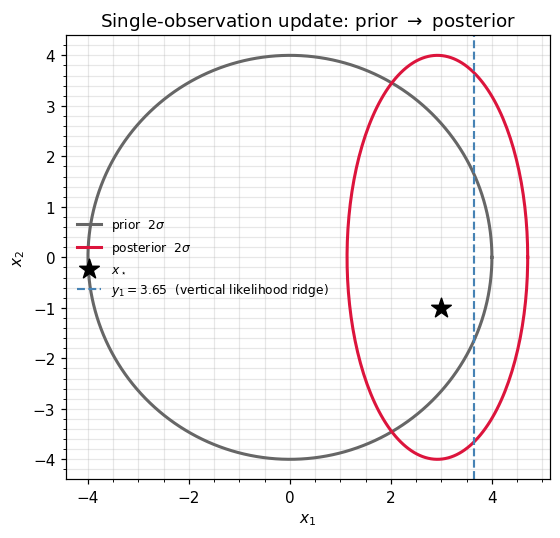

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.0))
prior_pts = ellipse_points(mu0, Sigma0)
post_pts  = ellipse_points(mu1_nat, S1_nat)
ax.plot(np.asarray(prior_pts[0]), np.asarray(prior_pts[1]),
        color="0.4", lw=2, label=r"prior  $2\sigma$")
ax.plot(np.asarray(post_pts[0]),  np.asarray(post_pts[1]),
        color="crimson", lw=2, label=r"posterior  $2\sigma$")
ax.scatter(*np.asarray(x_true), marker="*", s=180, color="k",
           label=r"$x_\star$", zorder=5)
ax.axvline(float(y1[0]), color="steelblue", lw=1.4, ls="--",
           label=fr"$y_1 = {float(y1[0]):.2f}$  (vertical likelihood ridge)")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(r"Single-observation update: prior $\to$ posterior")
ax.set_aspect("equal"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## Sequential updates: $N$ factors, one addition at a time

Five additional measurements, each through a different $H_i$ (single coordinates and diagonal projections), each with $R = 0.5$. The update rule is just [](#eq:bayes-natural) applied repeatedly:

```{math}
:label: eq:bayes-natural-recursion
\eta^{(n)} \;=\; \eta^{(n-1)} \;+\; \eta^{\rm lik}_n,
\qquad
\eta^{\rm lik}_n \;=\; \bigl(H_n^\top R_n^{-1} y_n,\;\; -\tfrac12\, H_n^\top R_n^{-1} H_n\bigr).
```

Each step is an array sum — no matrix inverses *during* the recursion. We only invert (via `to_expectation`) when we want to plot the running posterior.

In [5]:
H_list = [
    jnp.array([[0.0, 1.0]]),                       # y-coordinate
    jnp.array([[1.0, 1.0]]) / jnp.sqrt(2.0),       # diagonal
    jnp.array([[1.0, 0.0]]),                       # x-coordinate again
    jnp.array([[0.0, 1.0]]),                       # y-coordinate again
    jnp.array([[1.0, -1.0]]) / jnp.sqrt(2.0),      # anti-diagonal
]
R_obs = jnp.array([[0.5]])
R_obs_inv = jnp.linalg.inv(R_obs)

key = sub
ys = []
for H_i in H_list:
    key, k_obs = jax.random.split(key)
    y_i = einx.dot("k i, i -> k", H_i, x_true) \
        + jax.random.normal(k_obs, (1,)) * jnp.sqrt(R_obs[0, 0])
    ys.append(y_i)

# Recursion starting from the post-1 state.
eta1 = eta1_post1
eta2 = eta2_post1_mat

mus  = [mu0, mu1_nat]
Sigs = [Sigma0, S1_nat]

for n, (H_i, y_i) in enumerate(zip(H_list, ys, strict=True), start=2):
    eta1 = eta1 + einx.dot("k i, k l, l -> i", H_i, R_obs_inv, y_i)
    eta2 = eta2 + (-0.5) * einx.dot("k i, k l, l j -> i j", H_i, R_obs_inv, H_i)
    post_n = GaussianExpFam(eta1=eta1, eta2=psd_op(eta2))
    mu_n, S_n_op = to_expectation(post_n)
    mus.append(mu_n); Sigs.append(S_n_op.as_matrix())
    print(f"after obs {n}:  mu = [{float(mu_n[0]):+.3f}, {float(mu_n[1]):+.3f}]  "
          f"sqrt(tr Sigma) = {float(jnp.sqrt(jnp.trace(S_n_op.as_matrix()))):.3f}")

print(f"\nx_true = [{float(x_true[0]):.3f}, {float(x_true[1]):.3f}]")

after obs 2:  mu = [+2.920, -0.159]  sqrt(tr Sigma) = 1.116
after obs 3:  mu = [+2.622, -0.324]  sqrt(tr Sigma) = 0.933
after obs 4:  mu = [+2.988, -0.437]  sqrt(tr Sigma) = 0.765
after obs 5:  mu = [+3.130, -1.041]  sqrt(tr Sigma) = 0.668
after obs 6:  mu = [+2.816, -0.777]  sqrt(tr Sigma) = 0.592

x_true = [3.000, -1.000]


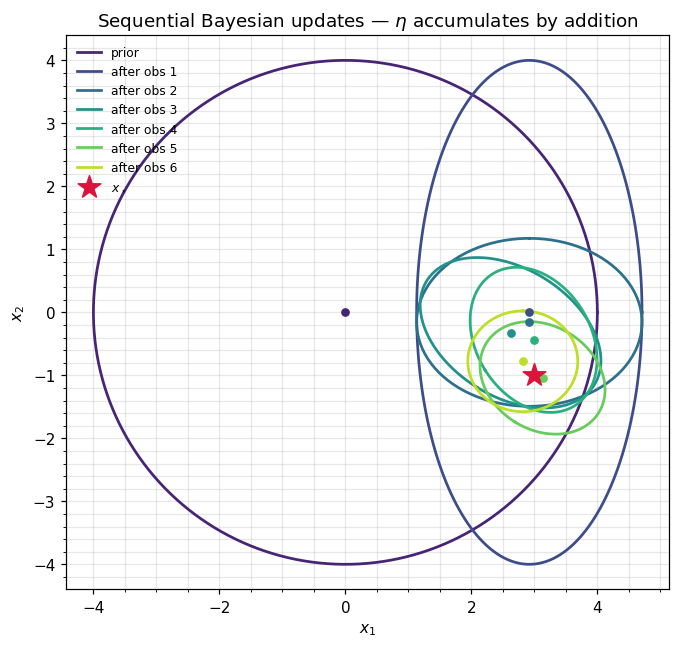

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 6.0))
n_steps = len(mus)
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, n_steps))
for k in range(n_steps):
    pts = ellipse_points(mus[k], Sigs[k])
    label = "prior" if k == 0 else f"after obs {k}"
    ax.plot(np.asarray(pts[0]), np.asarray(pts[1]),
            color=colors[k], lw=1.8, label=label)
    ax.scatter(float(mus[k][0]), float(mus[k][1]),
               s=22, color=colors[k], zorder=4)
ax.scatter(*np.asarray(x_true), marker="*", s=240, color="crimson",
           label=r"$x_\star$", zorder=5)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(r"Sequential Bayesian updates — $\eta$ accumulates by addition")
ax.set_aspect("equal"); ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## Batch = sequential = any order

Vector addition is commutative and associative, so the recursion [](#eq:bayes-natural-recursion) doesn't care in what order we apply the likelihood factors:

```{math}
:label: eq:order-independence
\eta^{\rm post}_N \;=\; \eta^{\rm prior} \;+\; \sum_{i=1}^{N} \eta^{\rm lik}_i \;=\; \eta^{\rm prior} \;+\; \sum_{i=1}^{N} \eta^{\rm lik}_{\pi(i)} \quad \text{for any permutation } \pi.
```

This is *not* a coincidence of Gaussian arithmetic — it's the defining property of exponential-family inference. Concretely:

In [7]:
# Stack ALL observations (including y1) and compare three computations.
H_all = [H1, *H_list]
y_all = [y1, *ys]
R_all = [R1, *([R_obs] * len(ys))]

def batch_natural(perm):
    eta1 = eta1_prior
    eta2 = eta2_prior_mat
    for j in perm:
        H, y, R = H_all[j], y_all[j], R_all[j]
        Rinv = jnp.linalg.inv(R)
        eta1 = eta1 + einx.dot("k i, k l, l -> i", H, Rinv, y)
        eta2 = eta2 + (-0.5) * einx.dot("k i, k l, l j -> i j", H, Rinv, H)
    return eta1, eta2

# (a) sequential = the order in which obs arrived
eta1_seq, eta2_seq = batch_natural(list(range(len(H_all))))
# (b) reversed
eta1_rev, eta2_rev = batch_natural(list(range(len(H_all)))[::-1])
# (c) random permutation
rng = np.random.default_rng(0)
perm = rng.permutation(len(H_all)).tolist()
eta1_rng, eta2_rng = batch_natural(perm)

ord_err_seq_rev = float(jnp.max(jnp.abs(eta1_seq - eta1_rev))) \
                + float(jnp.max(jnp.abs(eta2_seq - eta2_rev)))
ord_err_seq_rng = float(jnp.max(jnp.abs(eta1_seq - eta1_rng))) \
                + float(jnp.max(jnp.abs(eta2_seq - eta2_rng)))

# Compare to the running sequential trajectory's last entry.
last_post  = GaussianExpFam(eta1=eta1_seq, eta2=psd_op(eta2_seq))
mu_batch, S_batch_op = to_expectation(last_post)
S_batch = S_batch_op.as_matrix()

trajectory_last_mu  = mus[-1]
trajectory_last_Sig = Sigs[-1]

print(f"max ||eta(seq) - eta(reversed)||           = {ord_err_seq_rev:.2e}")
print(f"max ||eta(seq) - eta(random {perm})|| = {ord_err_seq_rng:.2e}")
print(f"max ||mu(batch)  - mu(traj last)||          = "
      f"{float(jnp.max(jnp.abs(mu_batch - trajectory_last_mu))):.2e}")
print(f"max ||Sig(batch) - Sig(traj last)||         = "
      f"{float(jnp.max(jnp.abs(S_batch - trajectory_last_Sig))):.2e}")

max ||eta(seq) - eta(reversed)||           = 1.78e-15
max ||eta(seq) - eta(random [3, 2, 5, 4, 0, 1])|| = 1.78e-15
max ||mu(batch)  - mu(traj last)||          = 0.00e+00
max ||Sig(batch) - Sig(traj last)||         = 0.00e+00


All differences sit at $\sim 10^{-15}$ — the recursion really is permutation-invariant up to round-off.

:::{important} Why this matters
Order-independence isn't just trivia. It says that Gaussian inference is *embarrassingly parallel*:
- **Distributed sensors** can sum their natural-form messages with no coordination.
- **Ensemble Kalman / data assimilation** can shuffle observations to break correlated batches.
- **EP** can re-visit factors in any order — the resulting fixed point depends only on which factors were considered, not when.

The flip side: the recursion **depends critically on the linear-Gaussian assumption**. With a non-Gaussian likelihood (e.g. classification), you need EP / VI to *project back* to a Gaussian after each multiplication, and order-independence breaks at the projection step.
:::

## GP regression *is* this update

Gaussian-process regression with a Gaussian likelihood is precisely [](#eq:bayes-natural) applied with $H = I$ (we observe the function directly) and $R = \sigma_n^2 I$:

```{math}
:label: eq:gp-as-bayes
\Lambda_{\rm post} \;=\; K^{-1} \;+\; \sigma_n^{-2} I,
\qquad
\mu_{\rm post} \;=\; \Lambda_{\rm post}^{-1}\,\sigma_n^{-2}\,y \;=\; K\,(K + \sigma_n^2 I)^{-1}\,y.
```

The standard GP posterior-mean formula on the right is [](joseph_form_update.ipynb#eq:cov-information) rearranged via the matrix-inversion identity. Different recipe, same equation.

Operationally, `gaussx` covers the whole loop:

GP log marginal likelihood : -19.557
posterior-mean RMSE vs sin : 0.1561


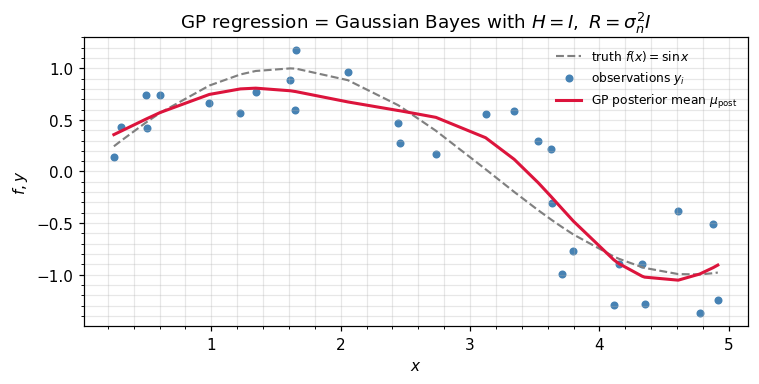

In [8]:
N_gp = 30
key, k_x, k_y = jax.random.split(KEY, 3)
xs = jnp.sort(jax.random.uniform(k_x, (N_gp,), minval=0.0, maxval=5.0))

# RBF kernel and noisy observations of f(x) = sin(x)
ls, sigma2 = 1.0, 0.1
diff = xs[:, None] - xs[None, :]
K_gp = jnp.exp(-0.5 * diff ** 2 / ls ** 2)
f_true = jnp.sin(xs)
y_gp   = f_true + jax.random.normal(k_y, (N_gp,)) * jnp.sqrt(sigma2)

# Posterior mean: K (K + sigma^2 I)^{-1} y  -- one structured solve.
K_op = psd_op(K_gp + sigma2 * jnp.eye(N_gp))
alpha = solve(K_op, y_gp)
mu_gp = einx.dot("i j, j -> i", K_gp, alpha)

# Log marginal likelihood — used downstream for hyperparameter learning.
lml = log_marginal_likelihood(loc=jnp.zeros(N_gp), cov_operator=K_op, y=y_gp)
rmse = float(jnp.sqrt(jnp.mean((mu_gp - f_true) ** 2)))
print(f"GP log marginal likelihood : {float(lml):.3f}")
print(f"posterior-mean RMSE vs sin : {rmse:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.plot(np.asarray(xs), np.asarray(f_true), "--", color="0.5",
        lw=1.4, label=r"truth $f(x) = \sin x$")
ax.scatter(np.asarray(xs), np.asarray(y_gp), s=18, color="steelblue",
           label=r"observations $y_i$")
ax.plot(np.asarray(xs), np.asarray(mu_gp), color="crimson", lw=2,
        label=r"GP posterior mean $\mu_{\rm post}$")
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$f, y$")
ax.set_title(r"GP regression = Gaussian Bayes with $H = I,\ R = \sigma_n^2 I$")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## Where this update lives in practice

| Setting | What "factor" means | Where in the curriculum |
|---------|---------------------|--------------------------|
| **Kalman filter** ([part 7](#)) | Each observation step = one Gaussian factor folded in via [](#eq:bayes-natural). The information form *is* the running natural-parameter sum; the standard form is its mean-cov twin. | Information-form filter / smoother. |
| **GP regression** ([part 3](#)) | All training observations are one big factor with $H=I, R=\sigma_n^2 I$. Posterior reduces to a single solve [](#eq:gp-as-bayes). | Exact, sparse, and approximate GP recipes. |
| **Ensemble Kalman / data assimilation** ([part 7.x](#)) | Each ensemble member or observation batch contributes a likelihood factor. Order-independence [](#eq:order-independence) lets you parallelise across sensors. | EnKF, particle Kalman, sequential 3D-Var. |
| **EP for non-Gaussian likelihoods** ([part 6](#)) | Each *site approximation* is a Gaussian factor in natural form. The cavity-tilted-update cycle is [](#eq:bayes-natural) with cavity = posterior − site, site = projection − cavity. | Classification GPs, robust regression. |
| **Conjugate Bayesian linear regression** | $H$ is the design matrix, $R = \sigma^2 I$. Sequential additions handle streaming data. | Recursive least squares as a degenerate Kalman filter. |
| **Distributed inference** | Each worker computes $\eta^{\rm lik}_w$ on its shard; the parameter server sums them. | Federated GP / Bayesian linear models. |

:::{tip} Rule of thumb
If your problem is **linear, Gaussian, and additive in evidence**, you don't need a fancy framework — you need [](#eq:bayes-natural) and a `for` loop. The moment you leave any of the three (non-linear $H$, non-Gaussian likelihood, non-additive structure), you're in approximate-inference territory and the natural-form sum becomes the *target* of an EP / VI step rather than the answer.
:::

## Recap

- Linear-Gaussian Bayes rule = one application of [](natural_parameters.ipynb#eq:natural-product) with the likelihood factor read off [](joseph_form_update.ipynb#eq:lin-gauss-model). No matrix inverses during the recursion.
- $N$ observations = $N$ additions: [](#eq:bayes-natural-recursion). Mean-cov / Joseph forms are equivalent recipes if you need $(\mu, \Sigma)$ at any point.
- **Order-independence** [](#eq:order-independence) is exact (modulo round-off) and is the reason exponential-family inference parallelises so cleanly.
- GP regression with a Gaussian likelihood is one shot of this update [](#eq:gp-as-bayes), executed via `gaussx.solve` on the structured operator $K + \sigma_n^2 I$.

:::{seealso} Where this goes
- **0.7 — Conditional distributions & Schur complement** — the *static* counterpart to this *sequential* update; conditioning vs filtering are two faces of the same Gaussian.
- **0.8 — Structured MVN sampling dispatch** — once you have $\mu_{\rm post}, \Sigma_{\rm post}$, drawing samples is a `root` dispatch.
- **Part 7 — State-space models** — same recursion, but with a *prediction* step injected between updates.
- **Part 6 — EP / VI** — when the likelihood factor stops being Gaussian, the inner loop computes a *Gaussian projection* of the tilted distribution and the recursion absorbs *that*.
:::

## References

- Bernardo, J. M. & Smith, A. F. M. (2000). *Bayesian Theory*. Wiley.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. §2.3.
- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press. §2.2.
- Minka, T. P. (2001). *A family of algorithms for approximate Bayesian inference*. PhD thesis, MIT.